In [214]:
import torch
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch import nn

In [215]:
X, y = make_moons(n_samples = 1000,
                 noise = 0.3,
                 random_state = 42)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[-0.1719,  0.5962],
         [ 1.2533, -0.2654],
         [ 0.7232,  0.2319],
         [-0.0652, -0.6552],
         [-0.7995,  0.5529]]),
 tensor([1., 1., 1., 1., 0.]))

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
len(X_train), len(y_train)

(800, 800)

In [217]:
class BC_Model(nn.Module):
    def __init__(self, input_feature, hidden_units, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_feature, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

model = BC_Model(input_feature=2, hidden_units=16, output_features=1)
model

BC_Model(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [218]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [219]:
from torchmetrics import Accuracy
acc_fn = Accuracy(task="binary")

In [220]:
epochs = 1000
for epoch in range(epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ##Testing
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = acc_fn(test_preds, y_test)

    if epoch%100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} , Train Acc: {acc:.5f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.5f}%")
    

Epoch: 0 | Train Loss: 0.68946 , Train Acc: 0.50500% | Test Loss: 0.68473, Test Acc: 0.55500%
Epoch: 100 | Train Loss: 0.35015 , Train Acc: 0.85125% | Test Loss: 0.36715, Test Acc: 0.80000%
Epoch: 200 | Train Loss: 0.31703 , Train Acc: 0.86375% | Test Loss: 0.32281, Test Acc: 0.83500%
Epoch: 300 | Train Loss: 0.30765 , Train Acc: 0.87000% | Test Loss: 0.30947, Test Acc: 0.85000%
Epoch: 400 | Train Loss: 0.29844 , Train Acc: 0.87375% | Test Loss: 0.29753, Test Acc: 0.85500%
Epoch: 500 | Train Loss: 0.28763 , Train Acc: 0.88000% | Test Loss: 0.28355, Test Acc: 0.85000%
Epoch: 600 | Train Loss: 0.27401 , Train Acc: 0.88125% | Test Loss: 0.26642, Test Acc: 0.86000%
Epoch: 700 | Train Loss: 0.25861 , Train Acc: 0.89000% | Test Loss: 0.24831, Test Acc: 0.87000%
Epoch: 800 | Train Loss: 0.24327 , Train Acc: 0.89750% | Test Loss: 0.23086, Test Acc: 0.90000%
Epoch: 900 | Train Loss: 0.23046 , Train Acc: 0.90750% | Test Loss: 0.21551, Test Acc: 0.90500%


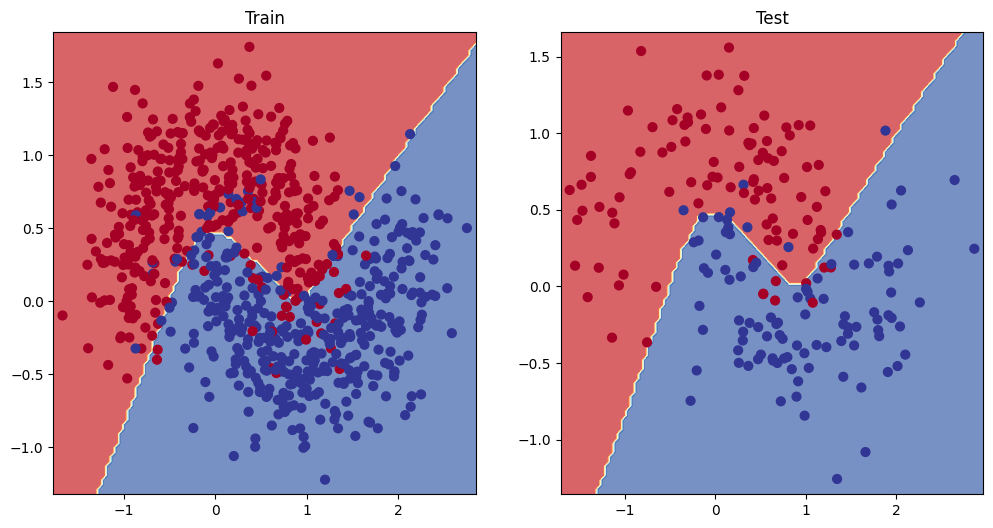

In [221]:
from helper_functions import plot_decision_boundary, plot_predictions
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [222]:
#replicate tanh function
def tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

In [223]:
tanh(torch.tensor(2))

tensor(0.9640)

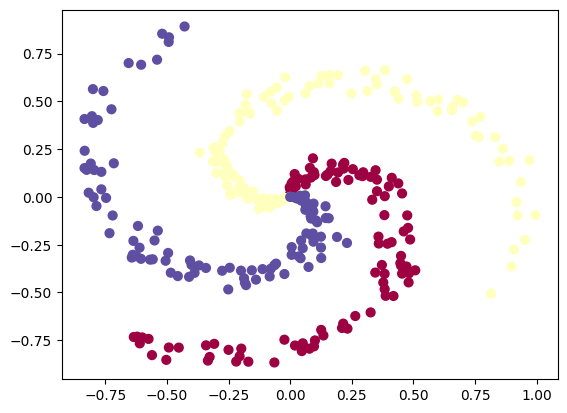

In [224]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [225]:
X[:5], y[:5]

(array([[-0.        ,  0.        ],
        [-0.00176672,  0.00994531],
        [ 0.00264176,  0.02002855],
        [ 0.00887787,  0.02897339],
        [ 0.00014625,  0.04040378]]),
 array([0, 0, 0, 0, 0], dtype=uint8))

In [226]:
X.shape, y.shape, type(X)

((300, 2), (300,), numpy.ndarray)

In [227]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [229]:
class MCC_Model(nn.Module):
    def __init__(self, input_features, hidden_units, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

model_2 = MCC_Model(input_features=2, hidden_units=16, output_features=4)
model_2

MCC_Model(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)

In [230]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.1)

In [231]:
y_train = y_train.long()
y_test = y_test.long()   
acc_fn = Accuracy(task="multiclass", num_classes=3)

epochs = 1000
for epoch in range(epochs):
    model_2.train()
    y_logits = model_2(X_train)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ##Testing
    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(X_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_test)
        test_acc = acc_fn(test_preds, y_test)

    if epoch%100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} , Train Acc: {acc:.5f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.5f}%")
    

Epoch: 0 | Train Loss: 1.41986 , Train Acc: 0.15000% | Test Loss: 1.13447, Test Acc: 0.45000%
Epoch: 100 | Train Loss: 0.03062 , Train Acc: 0.99167% | Test Loss: 0.01289, Test Acc: 1.00000%
Epoch: 200 | Train Loss: 0.01914 , Train Acc: 0.99167% | Test Loss: 0.00349, Test Acc: 1.00000%
Epoch: 300 | Train Loss: 0.01934 , Train Acc: 0.99167% | Test Loss: 0.00376, Test Acc: 1.00000%
Epoch: 400 | Train Loss: 0.01659 , Train Acc: 0.99167% | Test Loss: 0.00207, Test Acc: 1.00000%
Epoch: 500 | Train Loss: 0.01583 , Train Acc: 0.99167% | Test Loss: 0.00079, Test Acc: 1.00000%
Epoch: 600 | Train Loss: 0.01548 , Train Acc: 0.99167% | Test Loss: 0.00069, Test Acc: 1.00000%
Epoch: 700 | Train Loss: 0.01523 , Train Acc: 0.99167% | Test Loss: 0.00079, Test Acc: 1.00000%
Epoch: 800 | Train Loss: 0.01505 , Train Acc: 0.99167% | Test Loss: 0.00064, Test Acc: 1.00000%
Epoch: 900 | Train Loss: 0.01496 , Train Acc: 0.99167% | Test Loss: 0.00065, Test Acc: 1.00000%


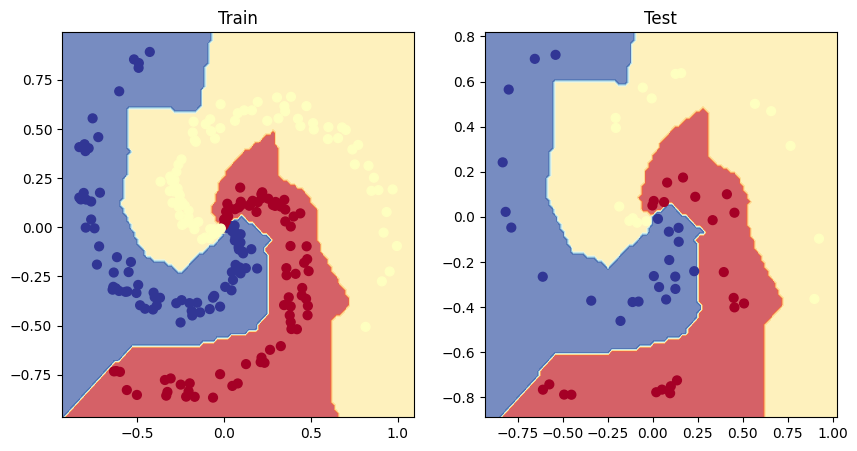

In [233]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)